In [1]:
###just copy all libraries from WorkShop..
# Core Libraries
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing and Model Selection
from scikeras.wrappers import KerasClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, cross_val_score

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

# Evaluation Metrics
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Upload the data
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df = pd.read_csv('mitbih_test.csv', header=None)
#Note: if we don't include header=none, i noticed that the first row o data is treated as the header and we lose data.

#Now make sure they're imported correctly and check the sahpes:
print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)



Training set shape: (87554, 188)
Testing set shape: (21892, 188)


In [3]:
#Check first few rows of data; to see what it looks like, to see the balance:
print(train_df.head())

#check last column is it 4 or 5 ? 
print(train_df.iloc[:, -1].unique())

#check how many samples there are per class?
print(train_df.iloc[:,-1].value_counts().sort_index())

        0         1         2         3         4         5         6    \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

        7         8         9    ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  187  
0  0.0  0.0  
1  0.0  0.0  
2  0.0  0.0  
3  0.0  0.0 

In [ ]:
"""
Very important things we can notice from the dataset:
-- our data is 1D numerical time-series ECG heartbeat signal data --
1- all values are between 0 - 1.
2- last column is 4 , lables are from 0 to 4 so no need for label encoding.
3- very very big imbalance in train classes!!?
Class 3 (Type2) only 641 sample comparing to 72,471 in class 0 !
That could cause in making the model lazy so we must create more samples for type 3 to train the model on.
***Keep in mind for the report***
"""


C:\Users\IT Support\AppData\Local\Temp\ipykernel_2760\947576283.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts.values, palette='viridis')


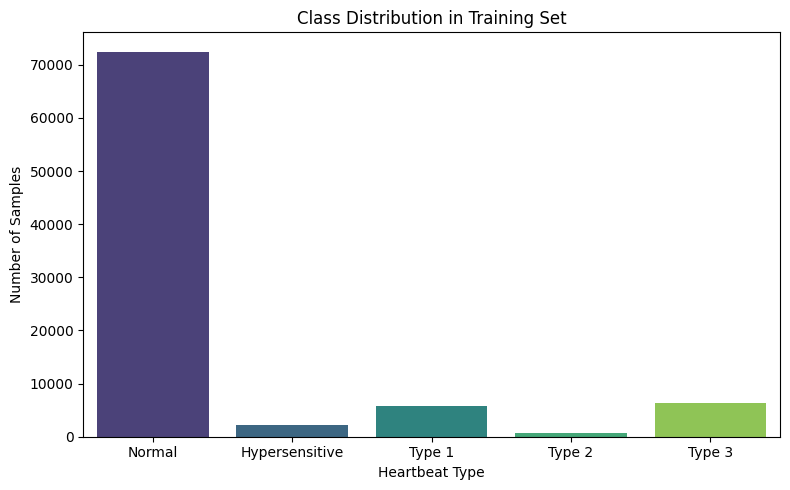


Percentage per class:
Class 0 (Normal): 72471 samples — 82.8%
Class 1 (Hypersensitive): 2223 samples — 2.5%
Class 2 (Type 1): 5788 samples — 6.6%
Class 3 (Type 2): 641 samples — 0.7%
Class 4 (Type 3): 6431 samples — 7.3%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualise the dataset, (More understanding) and look at the imbalance
class_names = ['Normal', 'Hypersensitive', 'Type 1', 'Type 2', 'Type 3']
class_counts = train_df.iloc[:, -1].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=class_counts.values, palette='viridis')
plt.title('Class Distribution in Training Set')
plt.xlabel('Heartbeat Type')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()
#### TO INCLUDE IN REPORT###
print("\nPercentage per class:")
for i, (count, name) in enumerate(zip(class_counts.values, class_names)):
    print(f"Class {i} ({name}): {count} samples — {count/len(train_df)*100:.1f}%")

In [ ]:
#it's obvious how bas the samples is so that is something to keep in mind
#Now must check the missing values in teaining and test values (datasets clean or not?)
print("Missing in training:")
print(train_df.isnull().sum().sum())
print("\nMissing in test:")
print(test_df.isnull().sum().sum())

# Result is 0, good. > Clean Data.


Missing in training:
0

Missing in test:
0


In [ ]:
#Before doing one hot encoding, i want to split the dta i want to split the data into x and y to do hot encoding to lables only.
X_train = train_df.iloc[:, :-1].values #all col. except thd last.
y_train = train_df.iloc[:, -1].values #last col. only.

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("First sample label:", y_train[0]) #Just to make sure.




X_train: (87554, 187)
y_train: (87554,)
X_test: (21892, 187)
y_test: (21892,)
First sample label: 0.0


In [ ]:
#Now One-Hot Encoding:
from tensorflow.keras.utils import to_categorical
#Converting lables to int. first, then encode.
y_train_encoded = to_categorical(y_train.astype(int), num_classes=5)
y_test_encoded = to_categorical(y_test.astype(int), num_classes=5)
print("y_train_encoded shape:", y_train_encoded.shape)
print("y_test_encoded shape:", y_test_encoded.shape)

#Now one hot encoding is done, start building CNN network.

y_train_encoded shape: (87554, 5)
y_test_encoded shape: (21892, 5)


In [ ]:
"""
Reshape the data: 
My first step will be adding the channels as CNN requires
"""
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train reshaped:", X_train_cnn.shape)
print("X_test reshaped:", X_test_cnn.shape)
#Now ready for CNN.

X_train reshaped: (87554, 187, 1)
X_test reshaped: (21892, 187, 1)
